# 02 EDA Auxiliary Tables

EDA for the auxiliary Home Credit tables:

- `bureau`
- `bureau_balance`
- `previous_application`
- `POS_CASH_balance`
- `credit_card_balance`
- `installments_payments`


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pl.Config.set_tbl_rows(10)
pl.Config.set_tbl_cols(12)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT / "src"))

from data_loading import read_table, scan_table

RAW_DIR = PROJECT_ROOT / "data" / "raw"
RAW_DIR

PosixPath('/mnt/c/Users/arand/OneDrive/Desktop/NEU/ds4400/final_project/data/raw')

In [2]:
TABLES = {
    "bureau": "SK_ID_CURR",
    "bureau_balance": "SK_ID_BUREAU",
    "previous_application": "SK_ID_CURR",
    "pos_cash_balance": "SK_ID_CURR",
    "credit_card_balance": "SK_ID_CURR",
    "installments_payments": "SK_ID_CURR",
}

STATUS_COLUMNS = {
    "bureau": "CREDIT_ACTIVE",
    "bureau_balance": "STATUS",
    "previous_application": "NAME_CONTRACT_STATUS",
    "pos_cash_balance": "NAME_CONTRACT_STATUS",
    "credit_card_balance": "NAME_CONTRACT_STATUS",
}

def collect_streaming(lf):
    return lf.collect(engine="streaming")

def table_overview(table_name, id_col):
    sample = read_table(table_name, n_rows=5)
    row_count = collect_streaming(scan_table(table_name).select(pl.len().alias("n_rows")))[0, "n_rows"]
    return {
        "table": table_name,
        "id_col": id_col,
        "rows": int(row_count),
        "cols": len(sample.columns),
        "sample_columns": ", ".join(sample.columns[:8]),
    }

def top_missing(table_name, top_n=10):
    row_count = collect_streaming(scan_table(table_name).select(pl.len().alias("n_rows")))[0, "n_rows"]
    null_counts = collect_streaming(scan_table(table_name).select(pl.all().null_count()))
    missing = []
    for column in null_counts.columns:
        count = int(null_counts[0, column])
        missing.append({
            "column": column,
            "null_count": count,
            "null_pct": 100 * count / row_count,
        })
    return pd.DataFrame(missing).sort_values("null_pct", ascending=False).head(top_n)

def records_per_id_summary(table_name, id_col):
    counts = collect_streaming(
        scan_table(table_name)
        .group_by(id_col)
        .agg(pl.len().alias("record_count"))
    )
    s = counts["record_count"].to_pandas()
    return {
        "table": table_name,
        "id_col": id_col,
        "unique_ids": int(len(s)),
        "mean_records": float(s.mean()),
        "median_records": float(s.median()),
        "p95_records": float(s.quantile(0.95)),
        "max_records": int(s.max()),
    }, s

def status_counts(table_name, column):
    return collect_streaming(
        scan_table(table_name)
        .group_by(column)
        .agg(pl.len().alias("count"))
        .sort("count", descending=True)
    ).to_pandas()


In [3]:
overview_df = pd.DataFrame([
    table_overview(table_name, id_col)
    for table_name, id_col in TABLES.items()
])
overview_df

,table,id_col,rows,cols,sample_columns
0,bureau,SK_ID_CURR,1716428,17,"SK_ID_CURR, SK_ID_BUREAU, CREDIT_ACTIVE, CREDI..."
1,bureau_balance,SK_ID_BUREAU,27299925,3,"SK_ID_BUREAU, MONTHS_BALANCE, STATUS"
2,previous_application,SK_ID_CURR,1670214,37,"SK_ID_PREV, SK_ID_CURR, NAME_CONTRACT_TYPE, AM..."
3,pos_cash_balance,SK_ID_CURR,10001358,8,"SK_ID_PREV, SK_ID_CURR, MONTHS_BALANCE, CNT_IN..."
4,credit_card_balance,SK_ID_CURR,3840312,23,"SK_ID_PREV, SK_ID_CURR, MONTHS_BALANCE, AMT_BA..."
5,installments_payments,SK_ID_CURR,13605401,8,"SK_ID_PREV, SK_ID_CURR, NUM_INSTALMENT_VERSION..."


In [4]:
for table_name in TABLES:
    print(f"\n{table_name}")
    display(read_table(table_name, n_rows=5).to_pandas())


bureau


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN



bureau_balance


,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C



previous_application


...

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0



credit_card_balance


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,...,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,...,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,...,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,...,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,...,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0



installments_payments


,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


In [5]:
record_summaries = []
record_distributions = {}

for table_name, id_col in TABLES.items():
    summary, distribution = records_per_id_summary(table_name, id_col)
    record_summaries.append(summary)
    record_distributions[table_name] = distribution

record_summary_df = pd.DataFrame(record_summaries)
record_summary_df.sort_values("mean_records", ascending=False)

,table,id_col,unique_ids,mean_records,median_records,p95_records,max_records
5,installments_payments,SK_ID_CURR,339587,40.064552,25.0,131.0,372
4,credit_card_balance,SK_ID_CURR,103558,37.083683,22.0,96.0,192
1,bureau_balance,SK_ID_BUREAU,817395,33.398693,26.0,90.0,97
3,pos_cash_balance,SK_ID_CURR,337252,29.655445,22.0,80.0,295
0,bureau,SK_ID_CURR,305811,5.612709,4.0,14.0,116
2,previous_application,SK_ID_CURR,338857,4.928964,4.0,13.0,77


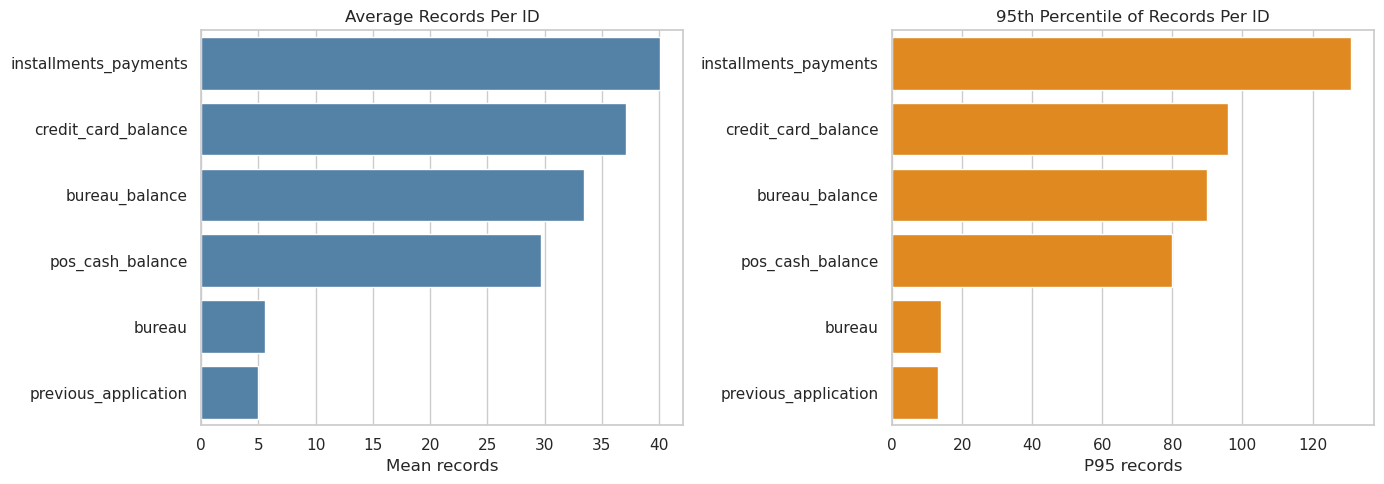

In [6]:
plot_df = record_summary_df.copy()
plot_df = plot_df.sort_values("mean_records", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=plot_df, x="mean_records", y="table", ax=axes[0], color="steelblue")
axes[0].set_title("Average Records Per ID")
axes[0].set_xlabel("Mean records")
axes[0].set_ylabel("")

sns.barplot(data=plot_df, x="p95_records", y="table", ax=axes[1], color="darkorange")
axes[1].set_title("95th Percentile of Records Per ID")
axes[1].set_xlabel("P95 records")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

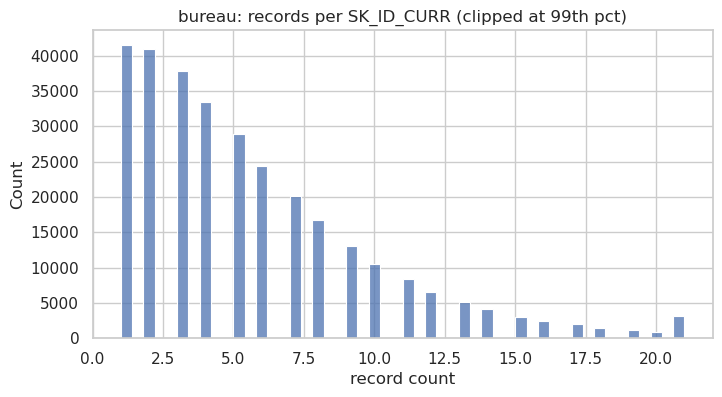

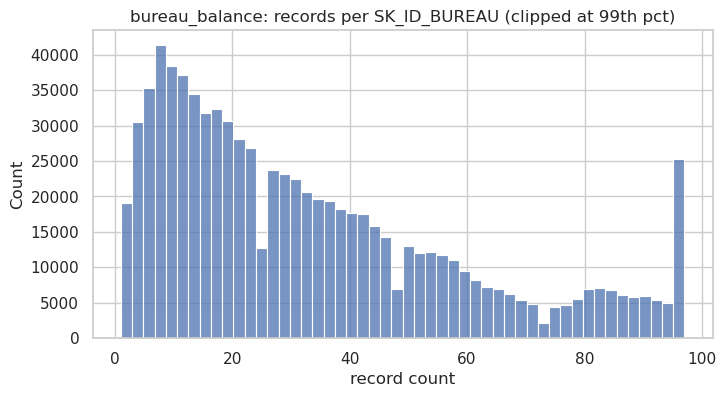

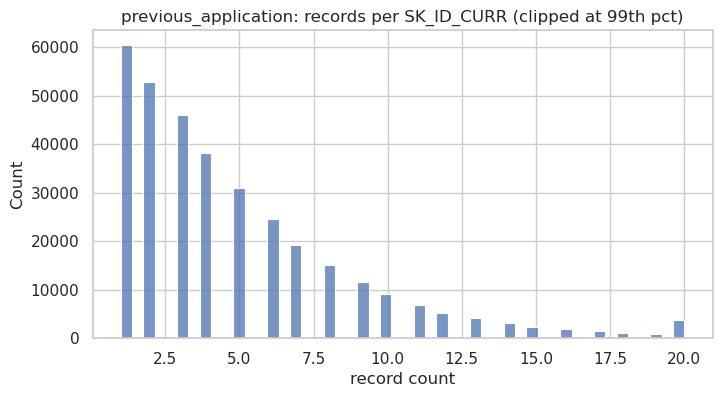

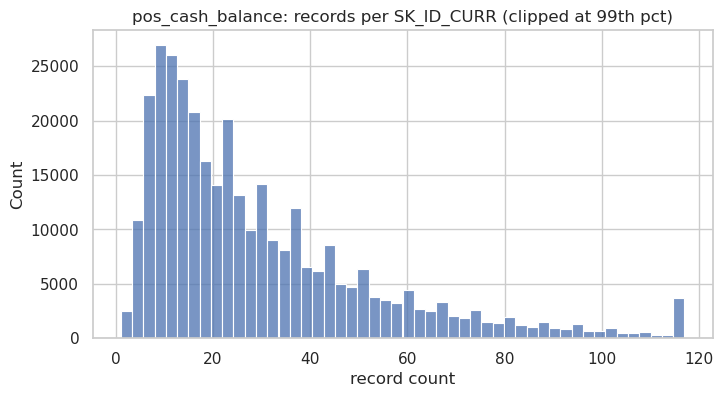

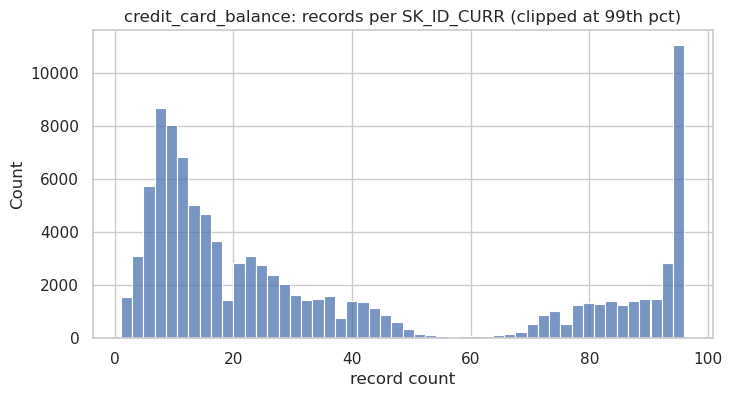

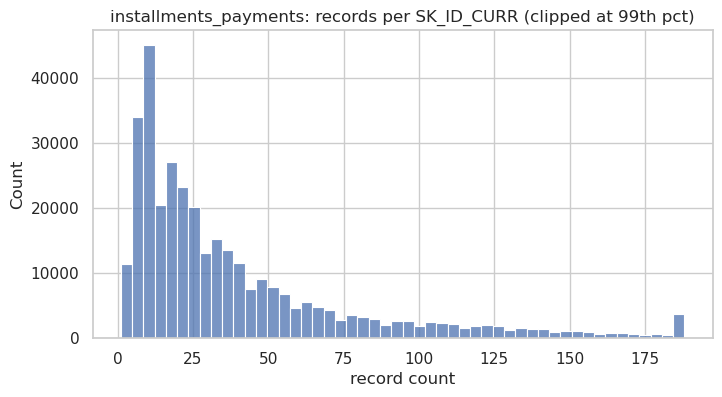

In [7]:
for table_name, series in record_distributions.items():
    plt.figure(figsize=(8, 4))
    sns.histplot(series.clip(upper=series.quantile(0.99)), bins=50)
    plt.title(f"{table_name}: records per {TABLES[table_name]} (clipped at 99th pct)")
    plt.xlabel("record count")
    plt.show()

In [8]:
for table_name in TABLES:
    print(f"\n{table_name}: top missing columns")
    display(top_missing(table_name, top_n=12))


bureau: top missing columns


,column,null_count,null_pct
16,AMT_ANNUITY,1226791,71.473490
8,AMT_CREDIT_MAX_OVERDUE,1124488,65.513264
7,DAYS_ENDDATE_FACT,633653,36.916958
12,AMT_CREDIT_SUM_LIMIT,591780,34.477415
11,AMT_CREDIT_SUM_DEBT,257669,15.011932
6,DAYS_CREDIT_ENDDATE,105553,6.149573
10,AMT_CREDIT_SUM,13,0.000757
0,SK_ID_CURR,0,0.000000
1,SK_ID_BUREAU,0,0.000000
5,CREDIT_DAY_OVERDUE,0,0.000000



bureau_balance: top missing columns


,column,null_count,null_pct
0,SK_ID_BUREAU,0,0.0
1,MONTHS_BALANCE,0,0.0
2,STATUS,0,0.0



previous_application: top missing columns


...

,column,null_count,null_pct
4,CNT_INSTALMENT_FUTURE,26087,0.260835
3,CNT_INSTALMENT,26071,0.260675
1,SK_ID_CURR,0,0.000000
0,SK_ID_PREV,0,0.000000
2,MONTHS_BALANCE,0,0.000000
5,NAME_CONTRACT_STATUS,0,0.000000
6,SK_DPD,0,0.000000
7,SK_DPD_DEF,0,0.000000



credit_card_balance: top missing columns


,column,null_count,null_pct
10,AMT_PAYMENT_CURRENT,767988,19.998063
18,CNT_DRAWINGS_POS_CURRENT,749816,19.524872
5,AMT_DRAWINGS_ATM_CURRENT,749816,19.524872
15,CNT_DRAWINGS_ATM_CURRENT,749816,19.524872
8,AMT_DRAWINGS_POS_CURRENT,749816,19.524872
7,AMT_DRAWINGS_OTHER_CURRENT,749816,19.524872
17,CNT_DRAWINGS_OTHER_CURRENT,749816,19.524872
19,CNT_INSTALMENT_MATURE_CUM,305236,7.948208
9,AMT_INST_MIN_REGULARITY,305236,7.948208
6,AMT_DRAWINGS_CURRENT,0,0.000000



installments_payments: top missing columns


,column,null_count,null_pct
7,AMT_PAYMENT,2905,0.021352
5,DAYS_ENTRY_PAYMENT,2905,0.021352
0,SK_ID_PREV,0,0.000000
1,SK_ID_CURR,0,0.000000
3,NUM_INSTALMENT_NUMBER,0,0.000000
2,NUM_INSTALMENT_VERSION,0,0.000000
4,DAYS_INSTALMENT,0,0.000000
6,AMT_INSTALMENT,0,0.000000



bureau: CREDIT_ACTIVE


,CREDIT_ACTIVE,count
0,Closed,1079273
1,Active,630607
2,Sold,6527
3,Bad debt,21


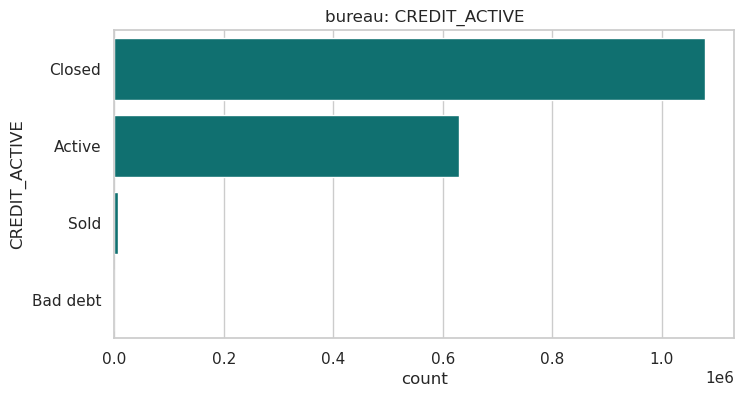


bureau_balance: STATUS


,STATUS,count
0,C,13646993
1,0,7499507
2,X,5810482
3,1,242347
4,5,62406
5,2,23419
6,3,8924
7,4,5847


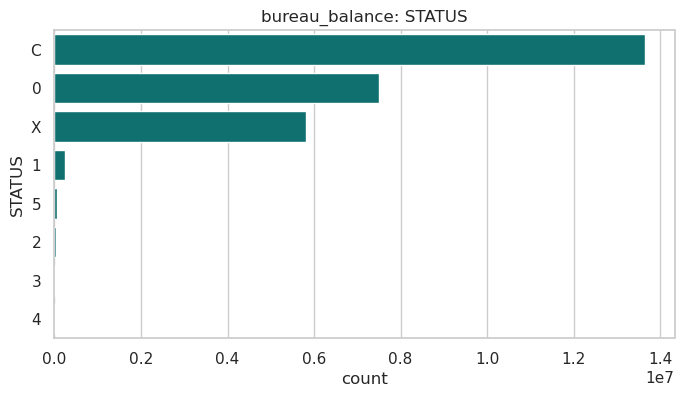


previous_application: NAME_CONTRACT_STATUS


,NAME_CONTRACT_STATUS,count
0,Approved,1036781
1,Canceled,316319
2,Refused,290678
3,Unused offer,26436


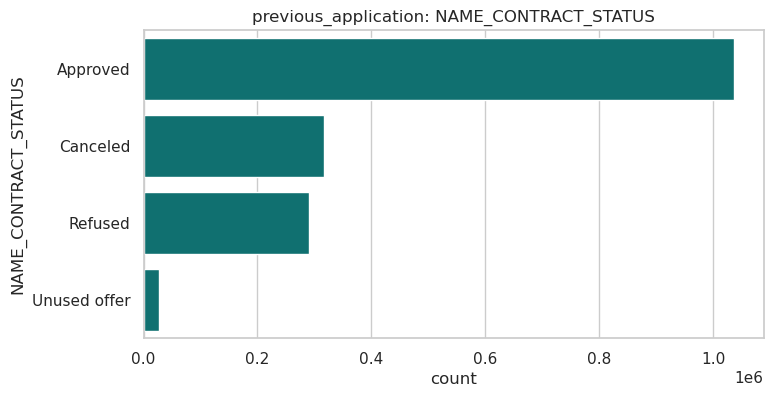


pos_cash_balance: NAME_CONTRACT_STATUS


,NAME_CONTRACT_STATUS,count
0,Active,9151119
1,Completed,744883
2,Signed,87260
3,Demand,7065
4,Returned to the store,5461
5,Approved,4917
6,Amortized debt,636
7,Canceled,15
8,XNA,2


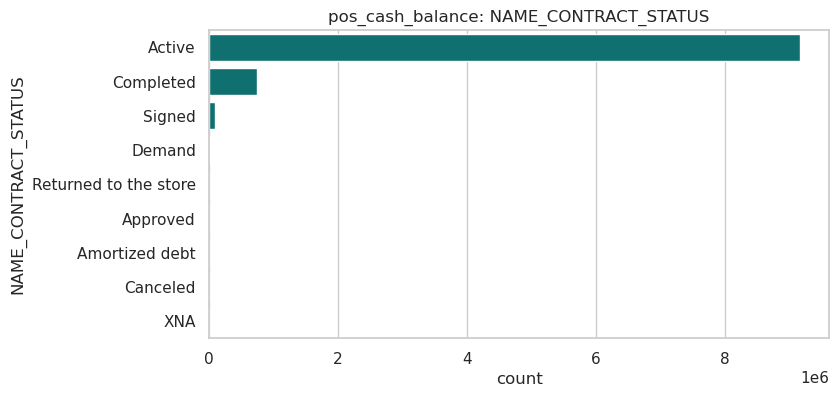


credit_card_balance: NAME_CONTRACT_STATUS


,NAME_CONTRACT_STATUS,count
0,Active,3698436
1,Completed,128918
2,Signed,11058
3,Demand,1365
4,Sent proposal,513
5,Refused,17
6,Approved,5


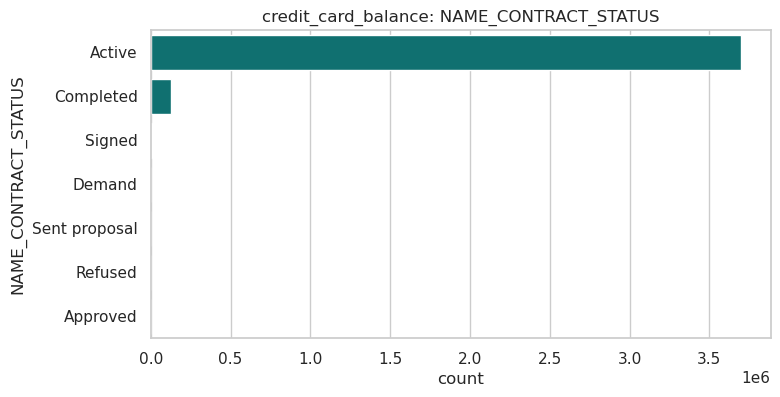

In [9]:
for table_name, column in STATUS_COLUMNS.items():
    counts = status_counts(table_name, column)
    print(f"\n{table_name}: {column}")
    display(counts)
    plt.figure(figsize=(8, 4))
    sns.barplot(data=counts, x="count", y=column, color="teal")
    plt.title(f"{table_name}: {column}")
    plt.show()